In [1]:
%load_ext autoreload
%autoreload 2

import os
from os.path import join
import numpy as np
from tqdm import tqdm
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import json

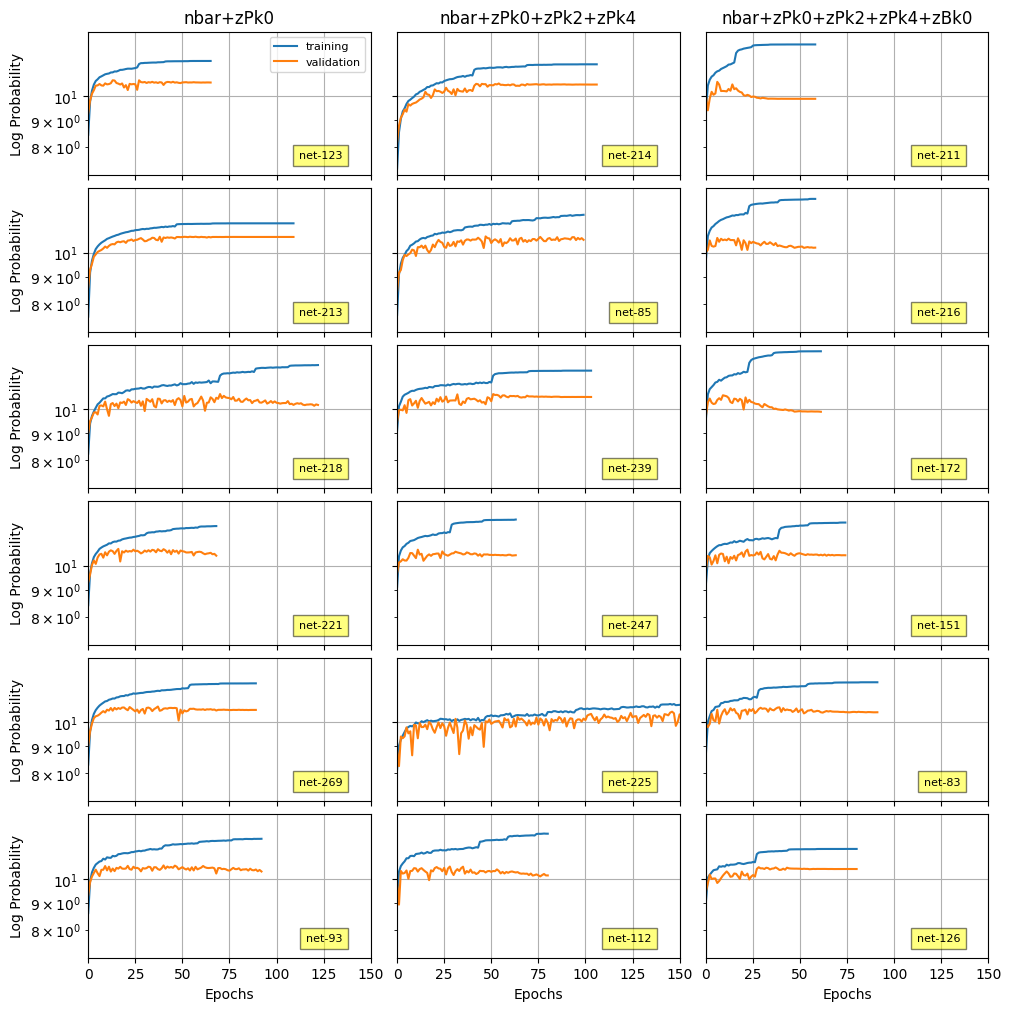

In [ ]:
netdirs = ['/anvil/scratch/x-mho1/cmass-ili/quijote/nbody_nonoise/models/galaxy/nbar+zPk0/kmin-0.0_kmax-0.4/nets',
           '/anvil/scratch/x-mho1/cmass-ili/quijote/nbody_nonoise/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4/nets',
           '/anvil/scratch/x-mho1/cmass-ili/quijote/nbody_nonoise/models/galaxy/nbar+zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4/nets']

N = 6
f, axs = plt.subplots(N, len(netdirs), figsize=(10, 10), sharex=True, sharey=True,
                      constrained_layout=True)

for k, netdir in enumerate(netdirs):
    axs[0, k].set_title(os.path.basename(
        os.path.dirname(os.path.dirname(netdir))))
    for i, n in enumerate(os.listdir(netdir)[:N]):
        filepath = join(netdir, n, 'summary.json')
        with open(filepath, 'r') as f:
            data = json.load(f)[0]
        ax = axs[i, k]
        ax.plot(data['training_log_probs'], label='training')
        ax.plot(data['validation_log_probs'], label='validation')
        ax.text(0.9, 0.1, n, transform=ax.transAxes,
                fontsize=8, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='k'))
        ax.grid()
        ax.set_xlim(0, 150)

for ax in axs[:, 0]:
    ax.set_yscale('log')
    ax.set_ylabel('Log Probability')
for ax in axs[-1, :]:
    ax.set_xlabel('Epochs')
axs[0, 0].legend(loc='upper right', fontsize=8)

In [ ]:
import os
from omegaconf import OmegaConf
from os.path import join
import numpy as np
from tqdm import tqdm


def get_cosmo(source_path):
    try:
        cfg = OmegaConf.load(join(source_path, 'config.yaml'))
        return np.array(cfg.nbody.cosmo)
    except Exception as e:
        print(f"Error loading cosmology parameters: {e} {source_path}")
        return None


# suitepath = '/ocean/projects/phy240015p/mho1/cmass-ili/quijotelike/fastpm/L1000-N128'
suitepath = '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_4k/L1000-N128'

cosmos = []
lhids = []
for d in tqdm(os.listdir(suitepath)[:]):
    cosmo = get_cosmo(join(suitepath, d))
    cosmos.append(cosmo)
    lhids.append(d)

cosmos = np.array(cosmos)
lhids = np.array(lhids)

 33%|███▎      | 1106/3333 [00:12<00:24, 92.25it/s]

In [ ]:
mask = (cosmos[:, 1] > 0.03) & (cosmos[:, 1] < 0.07)
np.sum(mask)

# for lhid in lhids[~mask]:
#     os.unlink(join(suitepath, lhid))

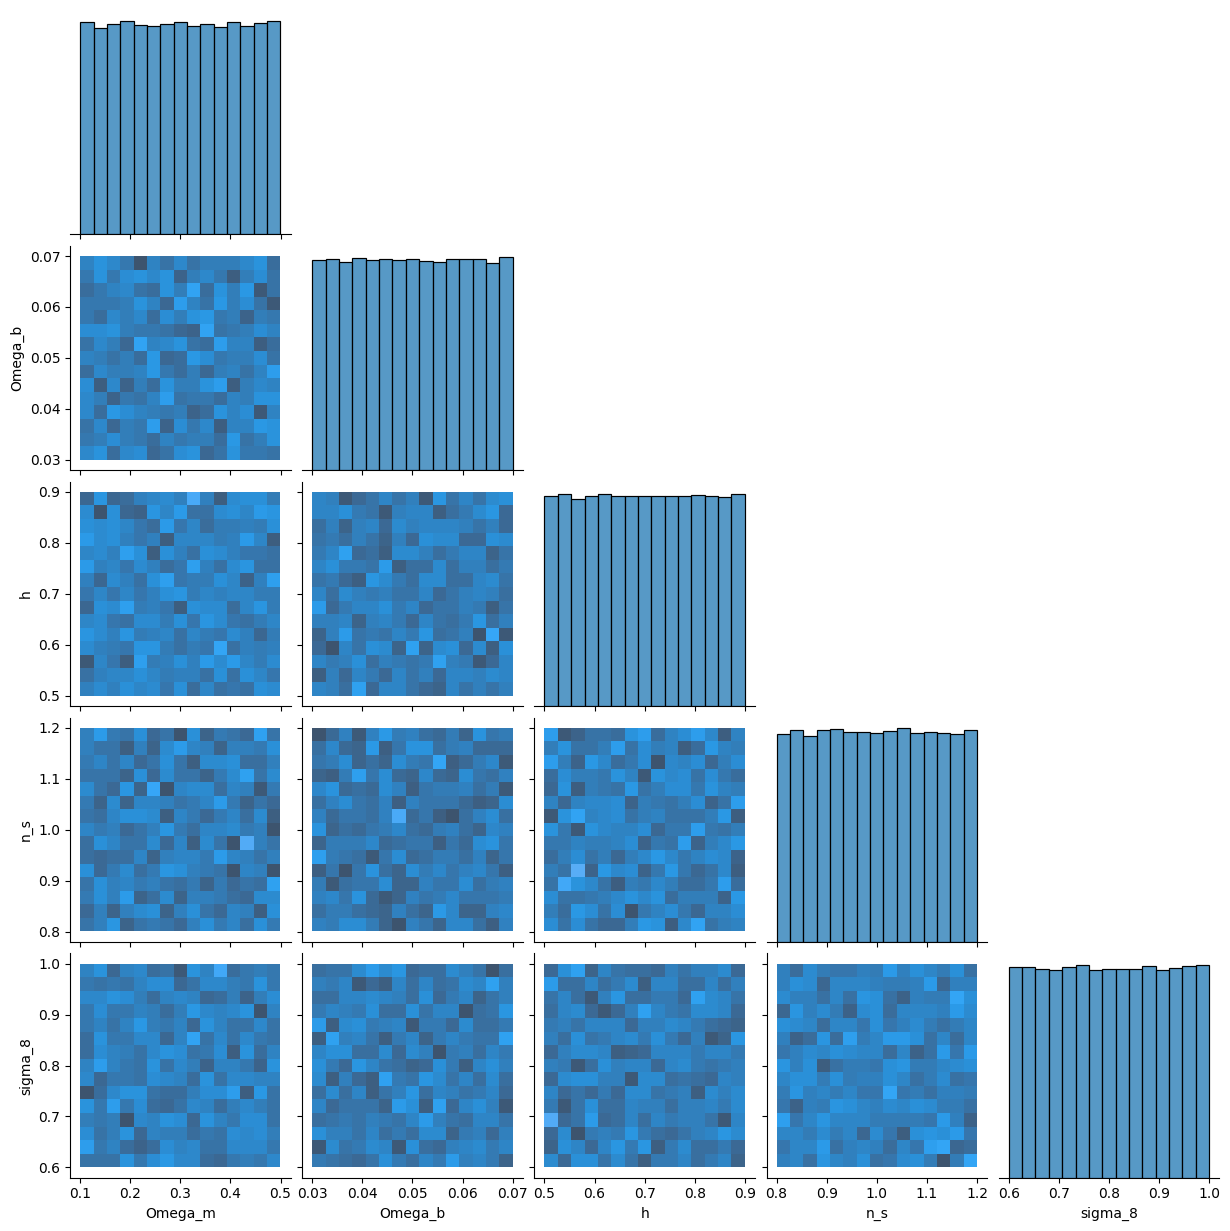

In [18]:
import seaborn as sns
# df_params = pd.read_csv(
#     '../params/latin_hypercube_params.txt', delim_whitespace=True, header=None).values
df_params = cosmos[mask]

cosmos_df = pd.DataFrame(
    df_params,
    columns=[
        'Omega_m',
        'Omega_b',
        'h',
        'n_s',
        'sigma_8'
    ]
)

# Generate a pair plot for the cosmos parameters
sns.pairplot(
    cosmos_df, kind='hist',
    corner=True, diag_kind="hist")